# Neutrino interaction rate vs detector distance, and the best Gaussian beam

Total $\nu$ interaction rate in the **signal volume** of the benchmark detector
(vertex tracker + argon TPC, $43~\mathrm{g/cm^2}$, $3.2$~t) from the $\mu^+$
beam, as one and the same detector is moved from a front face at $250$~m out to
$50$~km.

**The detector is the same physical object at every distance.** The benchmark
aperture has $\sigma_{\rm spot}\propto L$, so reloading it at a new distance
would *rebuild* it larger and keep its solid angle constant. Here $n_\sigma$ is
rescaled as $1/L$ so the physical aperture stays at the 5 km build
($R = 1.28 \to 2.41$~m) and only the distance changes.

**The Gaussian curves are fitted, not guessed.** We ask: what constant
divergence best reproduces the real lattice? Two answers are computed, both
fitted to the neutrino spot at $L = 5$~km and then used unchanged out to
$50$~km:

* one isotropic $\sigma$, matched to the radial spot size;
* separate $\sigma_{px},\sigma_{py}$, matched to the horizontal and vertical
  spot sizes independently.


In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import mint

N_EVALS = 1e5
L_FIT = 30e5                                  # fit the divergence at 10 km
R_CORE = 20e2                                # 20 m: the forward beam, not the arc halo
D_SCAN = np.geomspace(250e2, 50e5, 18)       # 250 m -> 50 km
det = mint.detectors.load("benchmark_5km")


def ring_with_divergence(sx, sy):
    '''Default ring with the transverse divergences replaced by constant
    Gaussians of width (sx, sy) [rad]. Orbit, envelope, dispersion and momentum
    spread are untouched.'''
    r = mint.lattices.load("mc_10tev_hybrid_v06")
    r.beamdiv_x = lambda u, _s=sx: np.full(np.shape(u), _s)
    r.beamdiv_y = lambda u, _s=sy: np.full(np.shape(u), _s)
    return r


def beam(ring=None, beam_dynamics=True, n_evals=N_EVALS):
    '''mu+ beam: the numubar simulation plus its exact nue reweighting.'''
    ring_, s_mb, ipy = mint.examples.standard_beam(
        nuflavor="numubar", direction="clockwise", n_evals=n_evals,
        beam_dynamics=beam_dynamics, ring=ring)
    s_e = s_mb.reweighted_copy(nuflavor="nue")
    s_e.place_muons_on_lattice(lattice=ring_, direction="clockwise")
    return s_mb, s_e, ipy


def half_width(v, w, frac=0.68):
    '''Half-width containing `frac` of the flux. A quantile, not an RMS: the
    angular distribution has a heavy non-Gaussian tail that would dominate a
    second moment.'''
    a = np.abs(np.asarray(v)); o = np.argsort(a)
    c = np.cumsum(w[o]); c /= c[-1]
    return float(np.interp(frac, c, a[o]))


def spot(sim, ipy, L=L_FIT):
    '''(x, y, w) of the flux at the plane z = L, within the beam core.'''
    _, w, rx, ry, *_ = det.face_rays(sim, exposure=ipy, dist=L, r_sel=R_CORE)
    return rx, ry, w

In [76]:
# --- reference simulations: the real lattice, and the same beam with the
# --- divergence switched off (the kernel the fit convolves)
s_real, _, ipy = beam()
s_zero, _, _ = beam(ring=ring_with_divergence(0.0, 0.0))

x_r, y_r, w_r = spot(s_real, ipy)
x_0, y_0, w_0 = spot(s_zero, ipy)

tgt_x, tgt_y = half_width(x_r, w_r), half_width(y_r, w_r)
tgt_r = half_width(np.hypot(x_r, y_r), w_r)
print(f"real lattice spot at {L_FIT/1e5:.0f} km (68% half-width):")
print(f"   x {tgt_x/100:.3f} m | y {tgt_y/100:.3f} m | radial {tgt_r/100:.3f} m")
print(f"zero-divergence spot:")
print(f"   x {half_width(x_0,w_0)/100:.3f} m | y {half_width(y_0,w_0)/100:.3f} m"
      f" | radial {half_width(np.hypot(x_0,y_0),w_0)/100:.3f} m")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(
/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


real lattice spot at 30 km (68% half-width):
   x 5.555 m | y 2.970 m | radial 6.927 m
zero-divergence spot:
   x 0.647 m | y 0.582 m | radial 0.990 m


In [77]:
# --- fit. A constant divergence adds an INDEPENDENT Gaussian to the muon
# --- direction, so the spot at L is the zero-divergence spot convolved with a
# --- Gaussian of width L*sigma. That makes each trial a resampling of one
# --- existing simulation instead of a new one (verified to <0.5% against
# --- direct simulation).
_rng = np.random.default_rng(7)
G1 = _rng.normal(0.0, 1.0, x_0.size)
G2 = _rng.normal(0.0, 1.0, x_0.size)


def smeared_width(sig_x, sig_y, which):
    xs, ys = x_0 + L_FIT*sig_x*G1, y_0 + L_FIT*sig_y*G2
    keep = np.hypot(xs, ys) < R_CORE          # same core cut as the simulation
    if which == "x":   return half_width(xs[keep], w_0[keep])
    if which == "y":   return half_width(ys[keep], w_0[keep])
    return half_width(np.hypot(xs, ys)[keep], w_0[keep])


BR = (1e-7, 1e-3)                              # rad, brackets the solution
sig_iso = brentq(lambda s: smeared_width(s, s, "r") - tgt_r, *BR, xtol=1e-9)
sig_px  = brentq(lambda s: smeared_width(s, 0.0, "x") - tgt_x, *BR, xtol=1e-9)
sig_py  = brentq(lambda s: smeared_width(0.0, s, "y") - tgt_y, *BR, xtol=1e-9)

print(f"BEST-FIT DIVERGENCES (matched to the {L_FIT/1e5:.0f} km spot)")
print(f"   isotropic : sigma        = {sig_iso*1e3:.3f} mrad")
print(f"   anisotropic: sigma_px    = {sig_px*1e3:.3f} mrad")
print(f"                sigma_py    = {sig_py*1e3:.3f} mrad")
print(f"\n   check -- radial width: fit {smeared_width(sig_iso,sig_iso,'r')/100:.3f} m"
      f" vs target {tgt_r/100:.3f} m")
print(f"   check -- x width:      fit {smeared_width(sig_px,sig_py,'x')/100:.3f} m"
      f" vs target {tgt_x/100:.3f} m")
print(f"   check -- y width:      fit {smeared_width(sig_px,sig_py,'y')/100:.3f} m"
      f" vs target {tgt_y/100:.3f} m")

BEST-FIT DIVERGENCES (matched to the 30 km spot)
   isotropic : sigma        = 0.146 mrad
   anisotropic: sigma_px    = 0.177 mrad
                sigma_py    = 0.096 mrad

   check -- radial width: fit 6.927 m vs target 6.927 m
   check -- x width:      fit 5.555 m vs target 5.555 m
   check -- y width:      fit 2.970 m vs target 2.970 m


In [78]:
CONFIGS = [
    ("real lattice", None, True),
    (rf"isotropic fit, $\sigma = {sig_iso*1e3:.2f}$ mrad",
     ring_with_divergence(sig_iso, sig_iso), True),
    (rf"anisotropic fit, $\sigma_{{px}} = {sig_px*1e3:.2f}$, "
     rf"$\sigma_{{py}} = {sig_py*1e3:.2f}$ mrad",
     ring_with_divergence(sig_px, sig_py), True),
    ("no beam dynamics", None, False),
]

sims = {}
for label, ring, bd in CONFIGS:
    sims[label] = (s_real, None, ipy) if label == "real lattice" else beam(ring, bd)
    print(f"{label[:60]:62s} ready")

real lattice                                                   ready


/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


isotropic fit, $\sigma = 0.15$ mrad                            ready
anisotropic fit, $\sigma_{px} = 0.18$, $\sigma_{py} = 0.10$    ready


/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


no beam dynamics                                               ready


In [79]:
def rate_vs_distance(s_mb, s_e, ipy_, D_scan=D_SCAN):
    '''Total nu interactions/yr in the signal volume vs front-face distance,
    with the detector held at its physical 5 km size.'''
    out = []
    for D in D_scan:
        det_D = mint.detectors.load("benchmark_5km", dist=D,
                                    n_sigma=2.5 * 5e5 / D)
        tot = 0.0
        for s_, fl in ((s_mb, "numubar"), (s_e, "nue")):
            tot += det_D.signal_interactions(s_, nuflavor=fl, sign=+1,
                                             exposure=ipy_)["total"]
        out.append(tot)
    return np.array(out)


# the real-lattice entry only stored the numubar sim; build its nue partner
_ring = mint.lattices.load("mc_10tev_hybrid_v06")
_s_e = s_real.reweighted_copy(nuflavor="nue")
_s_e.place_muons_on_lattice(lattice=_ring, direction="clockwise")
sims["real lattice"] = (s_real, _s_e, ipy)

rates = {lab: rate_vs_distance(*sims[lab]) for lab, *_ in CONFIGS}
for lab, *_ in CONFIGS:
    print(f"{lab[:58]:60s} {rates[lab][0]:.3e} -> {rates[lab][-1]:.3e}")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


real lattice                                                 1.835e+09 -> 4.770e+07
isotropic fit, $\sigma = 0.15$ mrad                          1.859e+09 -> 3.145e+07
anisotropic fit, $\sigma_{px} = 0.18$, $\sigma_{py} = 0.10   1.855e+09 -> 3.984e+07
no beam dynamics                                             1.820e+09 -> 1.138e+09


  L [km]     real lattice  isotropic fit,   anisotropic fit  no beam dynamic
    0.25        1.835e+09        1.859e+09        1.855e+09        1.820e+09
    0.34        1.766e+09        1.796e+09        1.790e+09        1.757e+09
    0.47        1.723e+09        1.767e+09        1.762e+09        1.729e+09
    0.64        1.668e+09        1.732e+09        1.726e+09        1.691e+09
    0.87        1.593e+09        1.683e+09        1.676e+09        1.643e+09
    1.19        1.515e+09        1.638e+09        1.629e+09        1.607e+09
    1.62        1.421e+09        1.571e+09        1.565e+09        1.578e+09
    2.22        1.299e+09        1.465e+09        1.473e+09        1.554e+09
    3.03        1.173e+09        1.353e+09        1.367e+09        1.534e+09
    4.13        1.048e+09        1.241e+09        1.252e+09        1.519e+09
    5.64        9.097e+08        1.073e+09        1.090e+09        1.509e+09
    7.71        7.365e+08        8.235e+08        8.666e+08        1.500e+09

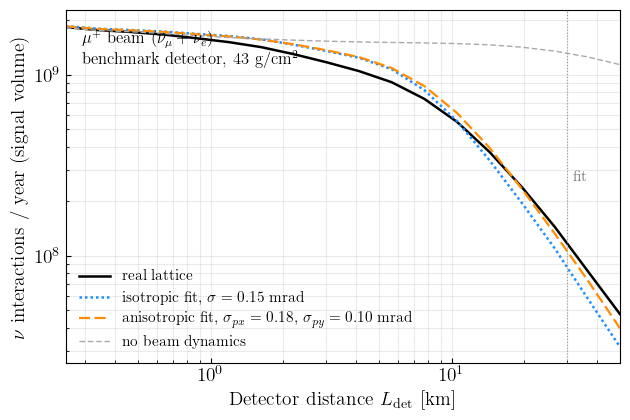

In [93]:
STYLE = [("black", "-", 1.8), ("dodgerblue", (0, (1, 1.2)), 1.8),
         ("darkorange", (0, (5, 2)), 1.6), ("darkgrey", (0, (4, 2)), 1)]

fig, ax = plt.subplots(figsize=(6.4, 4.3))
for (label, *_), (c, ls, lw) in zip(CONFIGS, STYLE):
    ax.plot(D_SCAN / 1e5, rates[label], color=c, ls=ls, lw=lw, label=label)
ax.axvline(L_FIT / 1e5, color="0.6", lw=0.8, ls=":")
ax.annotate("fit", xy=(L_FIT/1e5*1.06, 2.6e8), fontsize=11, color="0.45")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"Detector distance $L_{\rm det}$ [km]", fontsize=14)
ax.set_ylabel(r"$\nu$ interactions / year (signal volume)", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax.set_xlim(D_SCAN[0] / 1e5, D_SCAN[-1] / 1e5)
ax.grid(which="both", alpha=0.25)
ax.legend(frameon=False, fontsize=11, loc="lower left")
ax.annotate(r"$\mu^+$ beam ($\bar\nu_\mu + \nu_e$)" "\n"
            r"benchmark detector, $43~\mathrm{g/cm^2}$",
            xy=(0.03, 0.94), xycoords="axes fraction", fontsize=12,
            va="top", ha="left")
fig.tight_layout()
fig.savefig("../plots/nu_rate_vs_distance_divergence.pdf", dpi=300,
            bbox_inches="tight")

print(f"{'L [km]':>8s}" + "".join(f"{l[:15]:>17s}" for l, *_ in CONFIGS))
for i, D in enumerate(D_SCAN):
    print(f"{D/1e5:8.2f}" + "".join(f"{rates[l][i]:17.3e}" for l, *_ in CONFIGS))
i5 = int(np.argmin(abs(D_SCAN - L_FIT)))
print(f"\nrate at the fit point ({D_SCAN[i5]/1e5:.1f} km), relative to the real lattice:")
for l, *_ in CONFIGS:
    print(f"   {l[:50]:52s} {rates[l][i5]/rates['real lattice'][i5]:.3f}")

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_31117/3375664846.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


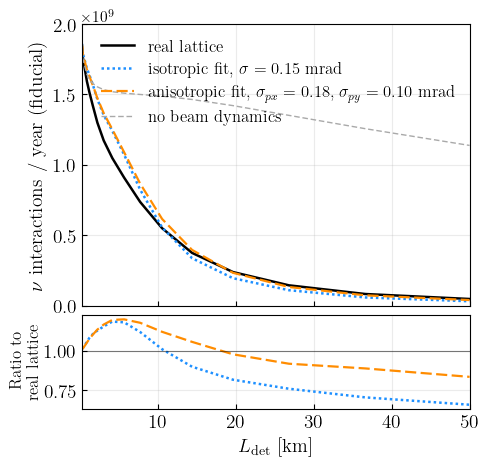

In [94]:
fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, 
                                    gridspec_kw={"hspace": 0.05, "height_ratios": [3, 1]})

for (label, *_), (c, ls, lw) in zip(CONFIGS, STYLE):
    ax.plot(D_SCAN / 1e5, rates[label], color=c, ls=ls, lw=lw, label=label)

# Plot ratios on bottom axis
real_lattice_rate = rates["real lattice"]
for (label, *_), (c, ls, lw) in zip(CONFIGS[1:3], STYLE[1:3]):
    ax_ratio.plot(D_SCAN / 1e5, rates[label] / real_lattice_rate, 
                  color=c, ls=ls, lw=lw, label=label)

ax.set_ylim(0, 2e9)
ax.set_ylabel(r"$\nu$ interactions / year (fiducial)", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax.set_xlim(D_SCAN[0] / 1e5, D_SCAN[-1] / 1e5)
ax.grid(which="both", alpha=0.25)
ax.legend(frameon=False, fontsize=12, loc="upper right")

ax_ratio.set_xlabel(r"$L_{\rm det}$ [km]", fontsize=14)
ax_ratio.set_ylabel(r"\noindent \,\, Ratio to \\real lattice", fontsize=12)
ax_ratio.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax_ratio.grid(which="both", alpha=0.25)
ax_ratio.axhline(y=1, color="black", ls="-", lw=0.8, alpha=0.5)

fig.tight_layout()
fig.savefig("../plots/nu_rate_vs_distance_divergence.pdf", dpi=300, bbox_inches="tight")


## Reading the result

Out to a few hundred metres the fixed $1.28$~m face subtends far more than the
decay cone, so every model collects the entire flux and the divergence does not
matter. The curves separate once $R/L$ falls to the scale of the divergence.

The two fits are constrained only by the spot at $5$~km, so how well they track
the real lattice elsewhere is a genuine test, not a fit result. The anisotropic
fit does better, which is the expected outcome: the real beam has
$\sigma_{px}\neq\sigma_{py}$, and a single isotropic width cannot reproduce both
projections at once.

Both Gaussian models sit **above** the real lattice at large $L_{\rm det}$. That
is the non-Gaussian tail: the true angular distribution puts more flux at large
angle than any Gaussian with the same core, so matching the core necessarily
underestimates the losses from a distant fixed aperture. The no-beam-dynamics
curve is the ceiling, where the cone is as narrow as $1/\gamma$ allows.


## Appendix: the originally-specified divergences

For comparison, the same scan with the two divergence values that were guessed
before the fit -- $\sigma_{px}=\sigma_{py}=0.1$~mrad and
$\sigma_{px}=0.08$, $\sigma_{py}=0.2$~mrad -- rather than the fitted ones. Both
are in the right ballpark, but the second has the anisotropy the wrong way
round: the real beam is wider horizontally than vertically ($\beta_x < \beta_y$
at the IP), so $\sigma_{px} > \sigma_{py}$, not the reverse.


In [87]:
CONFIGS_FIXED = [
    ("lattice", None, True),
    (r"$\sigma_{px}=\sigma_{py}=0.1$ mrad",
     ring_with_divergence(1.2e-4, 1.2e-4), True),
    (r"$\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad",
     ring_with_divergence(0.8e-4, 2.0e-4), True),
    ("no beam dynamics", None, False),
]

rates_fixed = {}
for label, ring, bd in CONFIGS_FIXED:
    if label in rates:                       # real lattice / no beam dynamics
        rates_fixed[label] = rates[label]    # already computed above
    else:
        rates_fixed[label] = rate_vs_distance(*beam(ring, bd))
    print(f"{label[:52]:54s} {rates_fixed[label][0]:.3e} -> {rates_fixed[label][-1]:.3e}")


/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


lattice                                                1.851e+09 -> 4.735e+07
$\sigma_{px}=\sigma_{py}=0.1$ mrad                     1.859e+09 -> 4.830e+07
$\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad             1.854e+09 -> 4.188e+07
no beam dynamics                                       1.820e+09 -> 1.138e+09


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_31117/1535313680.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



ratio to lattice at 26.8 km (guessed values vs the fitted ones):
   $\sigma_{px}=\sigma_{py}=0.1$ mrad               1.084
   $\sigma_{px}=0.08$, $\sigma_{py}=0.2$ mrad       0.918
   isotropic fit, $\sigma = 0.15$ mrad              0.760   (fitted)
   anisotropic fit, $\sigma_{px} = 0.18$, $\sigma   0.918   (fitted)


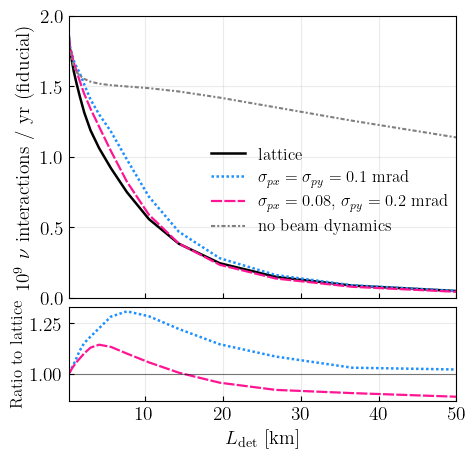

In [100]:
STYLE = [("black", "-", 1.8), ("dodgerblue", (0, (1, 1)), 1.8),
         ("deeppink", (0, (5, 1)), 1.6), ("grey", (0, (2, 1,1,1)), 1.5)]


fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(5, 5), sharex=True,
                                   gridspec_kw={"hspace": 0.05, "height_ratios": [3, 1]})

for (label, *_), (c, ls, lw) in zip(CONFIGS_FIXED, STYLE):
    ax.plot(D_SCAN / 1e5, rates_fixed[label]/1e9, color=c, ls=ls, lw=lw, label=label)

real_lattice_rate = rates_fixed["lattice"]
for (label, *_), (c, ls, lw) in zip(CONFIGS_FIXED[1:3], STYLE[1:3]):
    ax_ratio.plot(D_SCAN / 1e5, rates_fixed[label] / real_lattice_rate,
                  color=c, ls=ls, lw=lw, label=label)

ax.set_ylim(0, 2)
ax.set_ylabel(r"$10^9$ $\nu$ interactions / yr (fiducial)", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax.set_xlim(D_SCAN[0] / 1e5, D_SCAN[-1] / 1e5)
ax.grid(which="both", alpha=0.25)
ax.legend(frameon=False, fontsize=12, loc=(0.35, 0.2))

ax_ratio.set_xlabel(r"$L_{\rm det}$ [km]", fontsize=14)
ax_ratio.set_ylabel(r"\noindent \,\, Ratio to lattice", fontsize=12)
ax_ratio.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax_ratio.grid(which="both", alpha=0.25)
ax_ratio.axhline(y=1, color="black", ls="-", lw=0.8, alpha=0.5)

fig.tight_layout()
fig.savefig("../plots/nu_rate_vs_distance_divergence_fixed.pdf", dpi=300,
            bbox_inches="tight")

i5 = int(np.argmin(abs(D_SCAN - L_FIT)))
print(f"\nratio to lattice at {D_SCAN[i5]/1e5:.1f} km "
      f"(guessed values vs the fitted ones):")
for lab, *_ in CONFIGS_FIXED[1:3]:
    print(f"   {lab[:46]:48s} {rates_fixed[lab][i5]/real_lattice_rate[i5]:.3f}")
for lab, *_ in CONFIGS[1:3]:
    print(f"   {lab[:46]:48s} {rates[lab][i5]/rates['real lattice'][i5]:.3f}   (fitted)")
